In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.ticker import AutoMinorLocator

In [3]:
p_alpha = 0.05

n_obs, m_obs = 3, 2

data_x = np.array([-1.11, -6.10, 2.42])
data_y = np.array([-2.29, -2.91])

sigma2_x = 2
sigma2_y = 1

In [4]:
mean_diff = data_x.mean() - data_y.mean()

std_err = np.sqrt(sigma2_x / n_obs + sigma2_y / m_obs)

z_score = mean_diff / std_err

normal_gen = norm(loc=0, scale=1)

print(f"Разность средних (Delta): {mean_diff:.5f}")
print(f"Standard Error (SE): {std_err:.5f}")
print(f"Z-статистика (набл.): {z_score:.5f}")

Разность средних (Delta): 1.00333
Standard Error (SE): 1.08012
Z-статистика (набл.): 0.92891


In [5]:
z_threshold = normal_gen.ppf(1 - p_alpha)
print("Критическая точка Z_alpha: {:.5f}".format(z_threshold))

p_val = normal_gen.sf(z_score)
print(f"Рассчитанное p-value: {p_val:.5f}")

Критическая точка Z_alpha: 1.64485
Рассчитанное p-value: 0.17647


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\user\AppData\Local\Temp\ipykernel_16012\3813342969.py:8: SyntaxWarning: invalid escape sequence '\d'
  plot_ax.plot(d_grid, power_curve, label="Power $W(\delta)$", color="royalblue", linewidth=2.5)
C:\Users\user\AppData\Local\Temp\ipykernel_16012\3813342969.py:11: SyntaxWarning: invalid escape sequence '\d'
  plot_ax.set_xlabel("Истинное отклонение $\delta$", fontsize=12)


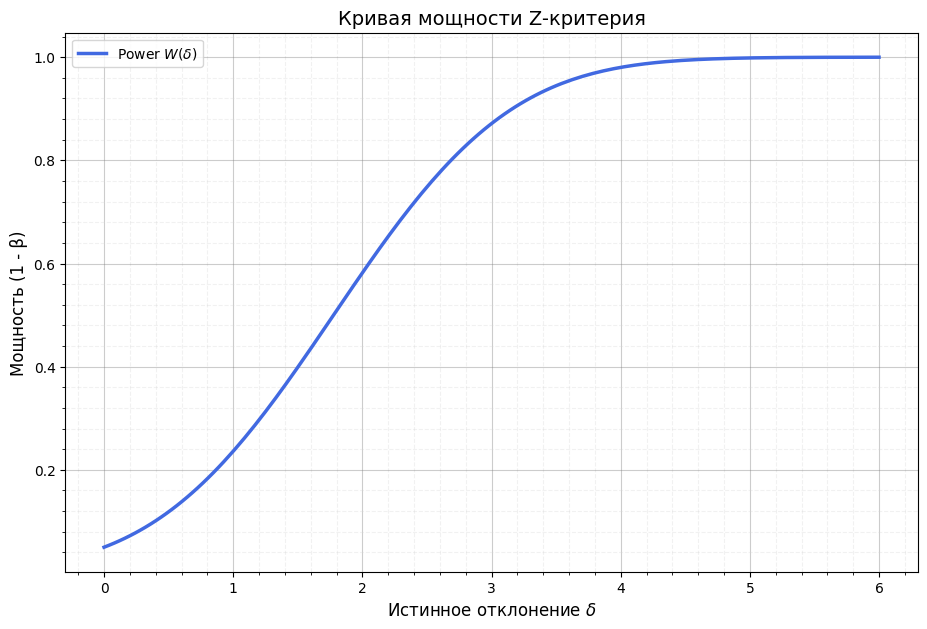

In [6]:
fig, plot_ax = plt.subplots(figsize=(11, 7))

d_grid = np.linspace(0, 6, 150)


power_curve = normal_gen.sf(z_threshold - d_grid / std_err)

plot_ax.plot(d_grid, power_curve, label="Power $W(\delta)$", color="royalblue", linewidth=2.5)

plot_ax.set_title("Кривая мощности Z-критерия", fontsize=14)
plot_ax.set_xlabel("Истинное отклонение $\delta$", fontsize=12)
plot_ax.set_ylabel("Мощность (1 - β)", fontsize=12)

plot_ax.xaxis.set_minor_locator(AutoMinorLocator(5))
plot_ax.yaxis.set_minor_locator(AutoMinorLocator(5))

plt.grid(which='major', color='gray', linestyle='-', alpha=0.4)
plt.grid(which='minor', color='lightgray', linestyle='--', alpha=0.3)

plt.legend(loc='upper left')
plt.show()